In [10]:
import pm4py
print(pm4py.__version__)
from pm4py import visualization
print(dir(visualization))
import json

# Load OCEL
ocel = pm4py.read_ocel2_json("commitizen_task_objects.json")

# Also load raw JSON for comparison
with open("commitizen_task_objects.json") as f:
    data = json.load(f)

print("Events:", len(ocel.events))
print("Objects:", len(ocel.objects))
print("Object types in OCEL:", len(ocel.objects[ocel.object_type_column].unique()))

2.7.19.8
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'bpmn', 'common', 'dfg', 'graphs', 'heuristics_net', 'importlib', 'network_analysis', 'ocel', 'performance_spectrum', 'petri_net', 'pm4_constants', 'process_tree', 'transition_system', 'trie']
Events: 21488
Objects: 6534
Object types in OCEL: 4


In [11]:
# Inspect OCEL object structure
import json

print("Object type column:", ocel.object_type_column)
print("\nDefined objectTypes (from JSON file):", [ot['name'] for ot in data['objectTypes']])

print("\nActually loaded in OCEL:")
print(ocel.objects[ocel.object_type_column].value_counts())

print("\nNote: Task objects exist in the JSON (1,721) but have no event relationships,")
print("so they are not included in the OCEL. Team objects are defined but not present in the data.")

Object type column: ocel:type

Defined objectTypes (from JSON file): ['issue', 'user', 'team', 'commit', 'task']

Actually loaded in OCEL:
ocel:type
commit    2765
task      1721
issue     1459
user       589
Name: count, dtype: int64

Note: Task objects exist in the JSON (1,721) but have no event relationships,
so they are not included in the OCEL. Team objects are defined but not present in the data.


In [12]:
print("\nDetailed object counts by type:")
print(ocel.objects[ocel.object_type_column].value_counts())


Detailed object counts by type:
ocel:type
commit    2765
task      1721
issue     1459
user       589
Name: count, dtype: int64


In [13]:
# Which commit implements a given task? task -> events -> commit

def commits_for_task(ocel, task_id):

    # events referencing this task
    events = ocel.relations[
        ocel.relations["ocel:oid"] == task_id
    ]["ocel:eid"].unique()

    # objects linked to those events
    related_objects = ocel.relations[
        ocel.relations["ocel:eid"].isin(events)
    ]["ocel:oid"].unique()

    # filter commit objects
    commits = [
        oid for oid in related_objects
        if ocel.objects.loc[oid]["ocel:type"] == "commit"
    ]

    return commits


In [14]:
# Which tasks did a resource implement? resource → events → tasks

def tasks_for_resource(ocel, resource_id):

    events = ocel.relations[
        ocel.relations["ocel:oid"] == resource_id
    ]["ocel:eid"].unique()

    related_objects = ocel.relations[
        ocel.relations["ocel:eid"].isin(events)
    ]["ocel:oid"].unique()

    tasks = [
        oid for oid in related_objects
        if ocel.objects.loc[oid]["ocel:type"] == "task"
    ]

    return tasks



In [15]:
# resource -> commit -> task

def resource_commit_task_map(ocel, resource_id):

    events = ocel.relations[
        ocel.relations["ocel:oid"] == resource_id
    ]["ocel:eid"].unique()

    result = []

    for eid in events:

        objs = ocel.relations[
            ocel.relations["ocel:eid"] == eid
        ]["ocel:oid"]

        commits = [o for o in objs if ocel.objects.loc[o]["ocel:type"] == "commit"]
        tasks = [o for o in objs if ocel.objects.loc[o]["ocel:type"] == "task"]

        for c in commits:
            for t in tasks:
                result.append((resource_id, c, t, eid))

    return result


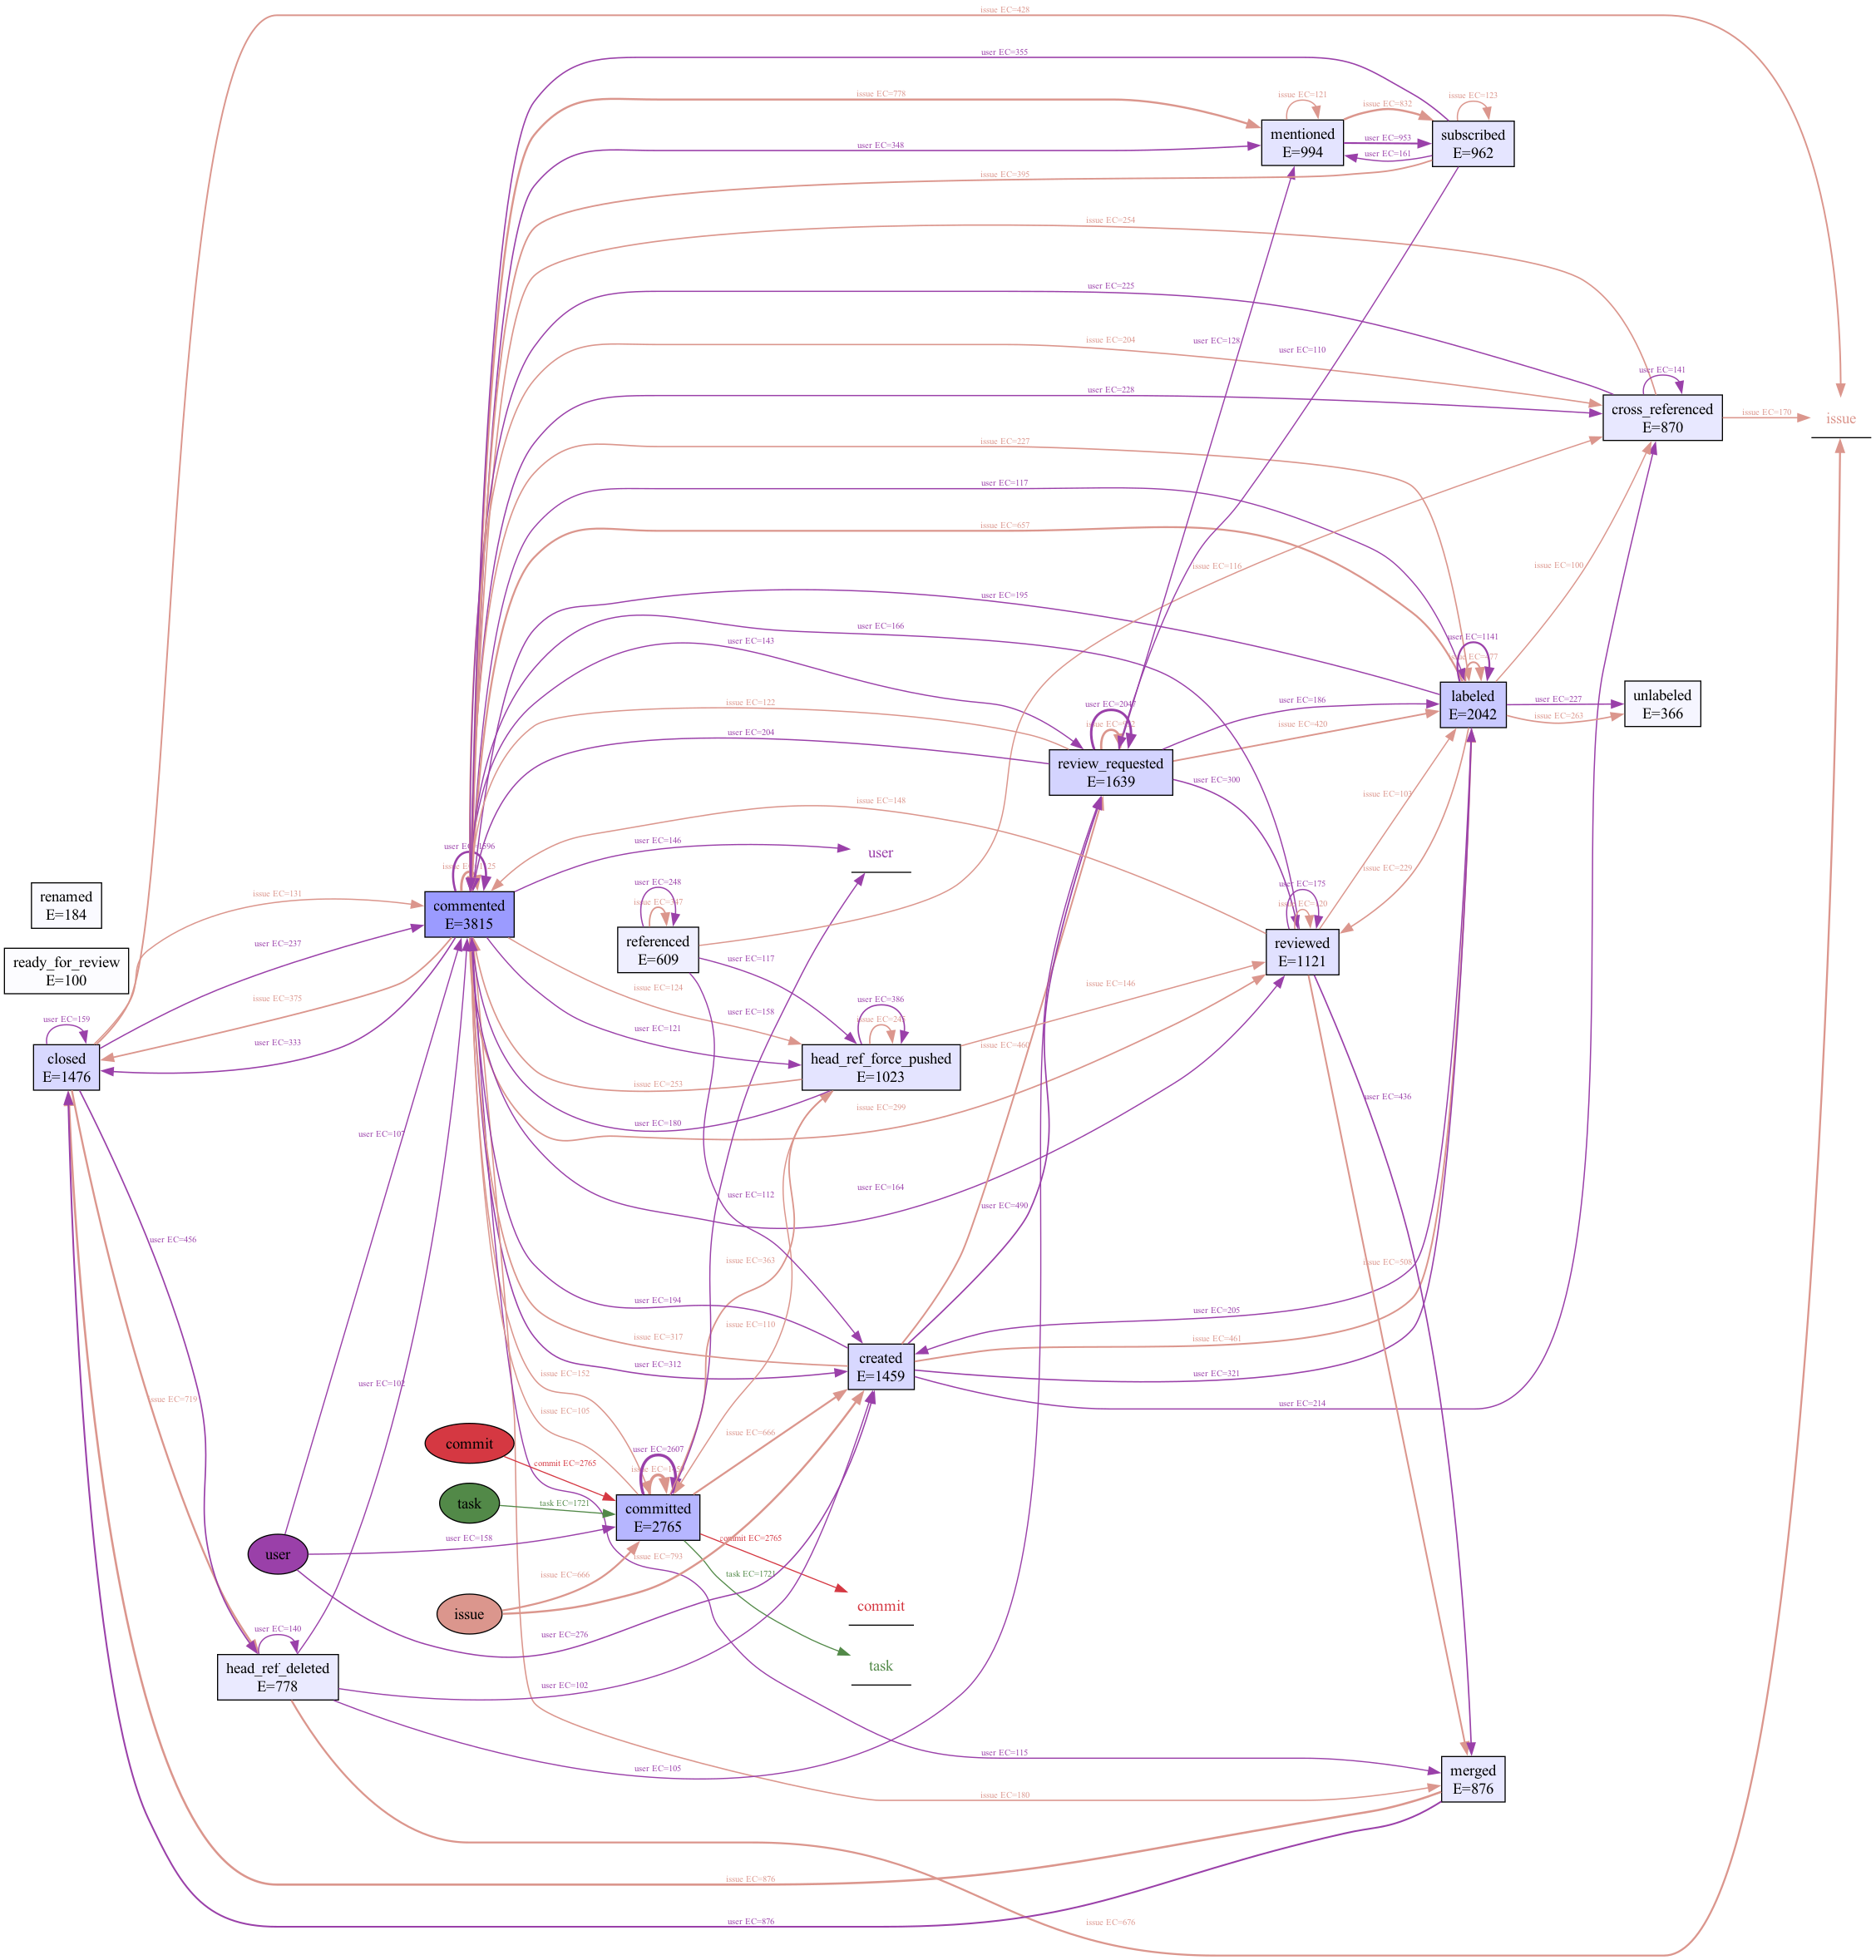

In [58]:
from pm4py.algo.discovery.ocel.ocdfg import algorithm
from pm4py.visualization.ocel.ocdfg import visualizer as ocdfg_visualizer

# 1. Build the object (this might still be big)
ocdfg_obj = algorithm.apply(ocel)

# 2. Force the visualizer to prune the edges and nodes
# 'p' is the dependency threshold (0.0 to 1.0)
# 'm' is the frequency threshold
viz_params = {
    "annotation": "frequency",
    "act_threshold": 100,    # Minimum frequency for an activity to appear
    "edge_threshold": 100,   # Minimum frequency for a relationship to appear
    "performance_aggregation": "mean"
}

graph = ocdfg_visualizer.apply(ocdfg_obj, parameters=viz_params)
ocdfg_visualizer.view(graph)


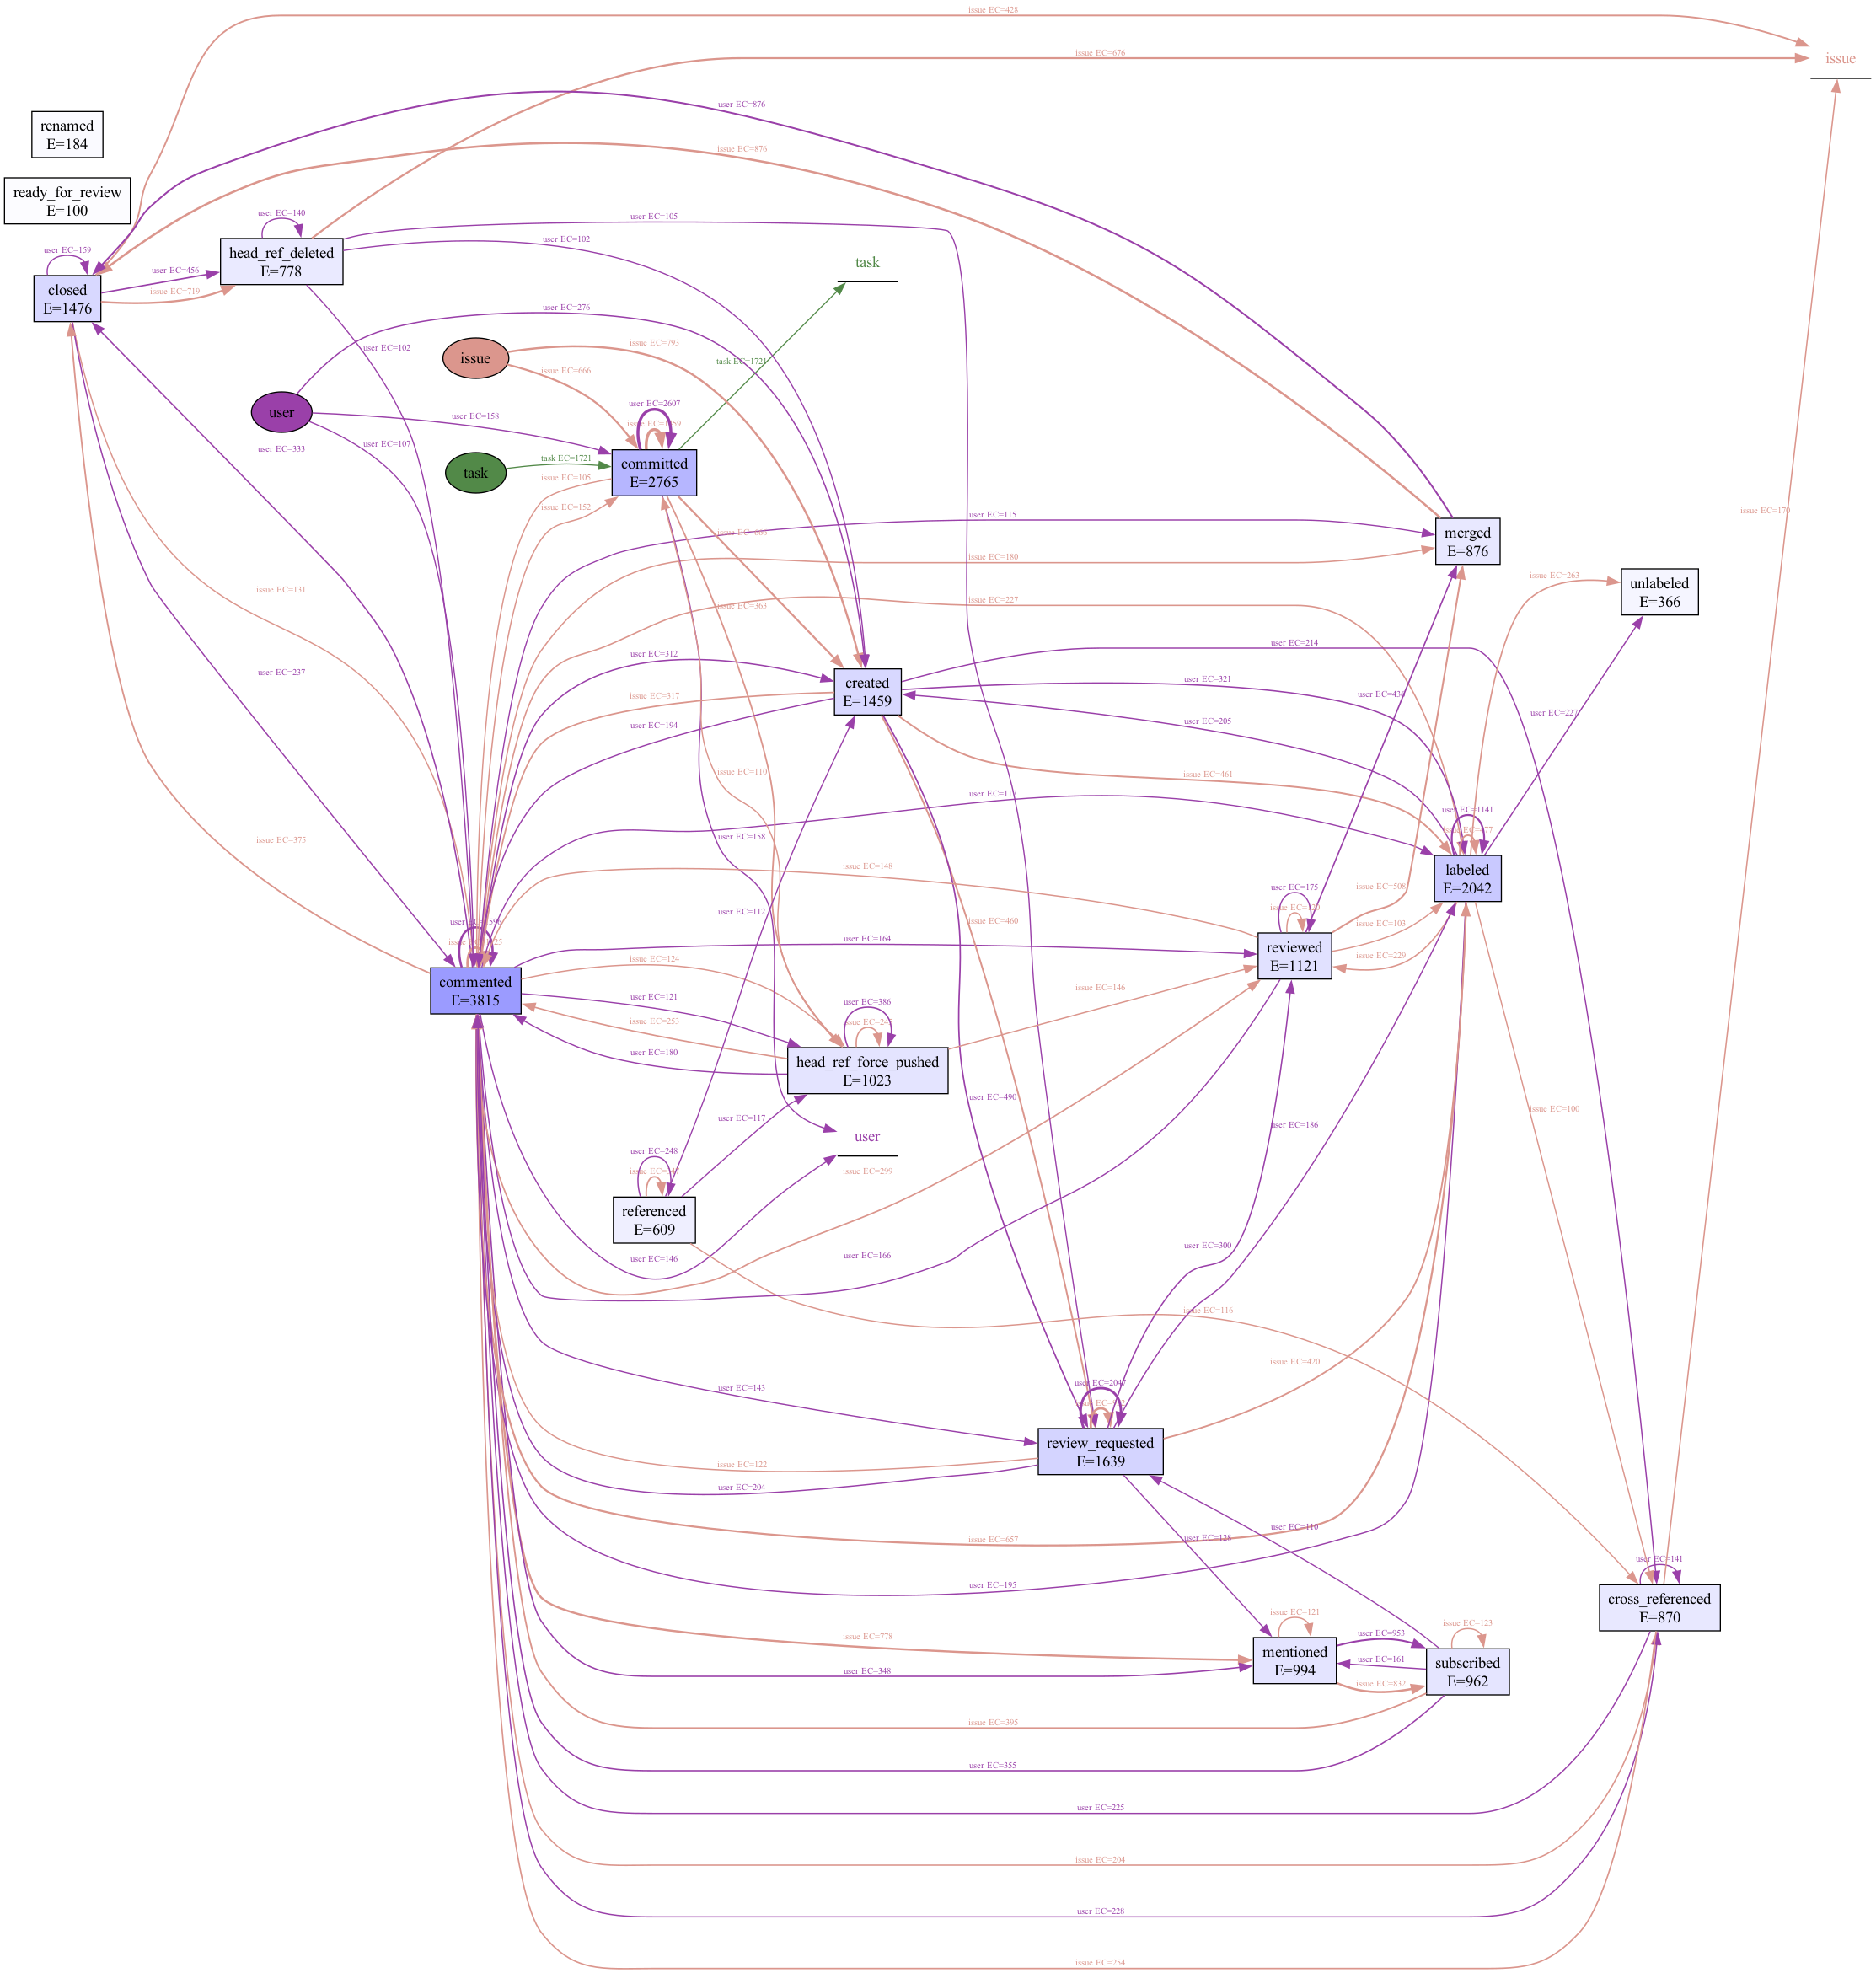

In [73]:
filtered = pm4py.filter_ocel_object_types(
    ocel,
    ["task", "issue", "user"]
)

ocdfg_obj = algorithm.apply(filtered)

graph = ocdfg_visualizer.apply(ocdfg_obj, parameters=viz_params)
ocdfg_visualizer.view(graph)

In [71]:
print(ocel.relations.head())

      ocel:eid ocel:activity            ocel:timestamp ocel:oid ocel:type  \
2190     97813       created 2017-11-04 10:09:22+00:00    97809     issue   
2191     97813       created 2017-11-04 10:09:22+00:00    97816      user   
24433    97823     commented 2017-11-04 14:32:12+00:00       36      user   
24434    97823     commented 2017-11-04 14:32:12+00:00    97809     issue   
36217    97827        closed 2017-11-27 12:35:03+00:00       36      user   

       ocel:qualifier  
2190          created  
2191          created  
24433           actor  
24434  timeline_event  
36217           actor  
